# Day_24_Feature Engineering and sklearn Pipelines


### Part A — Build features

### TASK 01 — Engineer features from existing columns

In [47]:
# ================================================================
# TASK 01 — Feature Engineering from Existing Columns
# ================================================================
# Goal:
# 1. Train a model using only the raw numeric columns (baseline).
# 2. Create at least 3 engineered features using existing columns.
# 3. Train the same model again using the engineered features.
# 4. Compare the baseline and engineered-feature scores.
# 5. Explain what information each engineered feature exposes.
# ================================================================


# ------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------
# 3. Define target and raw numeric features
# ------------------------------------------------
# Target:
# churn = 1 -> customer churned
# churn = 0 -> customer did not churn

target = "churn"

# Only raw numeric columns are used for the baseline model.
raw_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

X_raw = df[raw_features].copy()
y = df[target].copy()


# ------------------------------------------------
# 4. Train/test split
# ------------------------------------------------
# We use the SAME split for both models so that
# the baseline and engineered models are compared fairly.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------
# 5. Create the baseline model
# ------------------------------------------------
# Pipeline:
# Median imputation -> StandardScaler -> Logistic Regression
#
# Median imputation is required because total_charges
# contains some missing values.

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])


# ------------------------------------------------
# 6. Train baseline model
# ------------------------------------------------
baseline_model.fit(X_train_raw, y_train)

baseline_predictions = baseline_model.predict(X_test_raw)

baseline_score = accuracy_score(
    y_test,
    baseline_predictions
)

print("\n" + "=" * 60)
print("BASELINE MODEL")
print("=" * 60)
print("Raw numeric features:", raw_features)
print(f"Baseline Test Accuracy: {baseline_score:.4f}")
print(f"Baseline Test Accuracy: {baseline_score * 100:.2f}%")


# ================================================================
# 7. FEATURE ENGINEERING
# ================================================================
# We create new features ONLY from existing columns.
#
# No external data is added.
# ================================================================

X_engineered = X_raw.copy()


# ------------------------------------------------
# Feature 1: Average monthly spend
# ------------------------------------------------
# Formula:
#
# total_charges / tenure_months
#
# This gives an estimate of how much the customer
# has paid per month over their entire tenure.

X_engineered["avg_monthly_spend"] = (
    X_engineered["total_charges"] /
    X_engineered["tenure_months"].replace(0, np.nan)
)


# ------------------------------------------------
# Feature 2: Monthly charge relative to age
# ------------------------------------------------
# Formula:
#
# monthly_charges / age
#
# This represents the customer's monthly charge
# relative to their age.
#
# It combines two variables into one meaningful
# "charge relative to age" measure.

X_engineered["charge_per_age"] = (
    X_engineered["monthly_charges"] /
    X_engineered["age"].replace(0, np.nan)
)


# ------------------------------------------------
# Feature 3: Monthly charge × tenure
# ------------------------------------------------
# Formula:
#
# monthly_charges * tenure_months
#
# This represents the approximate cumulative
# charge implied by the current monthly charge
# over the customer's tenure.
#
# It captures an interaction between price and
# customer duration.

X_engineered["monthly_charge_tenure"] = (
    X_engineered["monthly_charges"] *
    X_engineered["tenure_months"]
)


# Replace infinite values with NaN.
# The pipeline will handle missing values using
# median imputation.

X_engineered = X_engineered.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------
# 8. Display the engineered features
# ------------------------------------------------

engineered_features = [
    "avg_monthly_spend",
    "charge_per_age",
    "monthly_charge_tenure"
]

print("\n" + "=" * 60)
print("ENGINEERED FEATURES")
print("=" * 60)

print(X_engineered[engineered_features].head())


# ------------------------------------------------
# 9. Train/test split for engineered features
# ------------------------------------------------
# Use exactly the same random_state and stratification
# as the baseline model.

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------
# 10. Create and train engineered-feature model
# ------------------------------------------------

engineered_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

engineered_model.fit(
    X_train_eng,
    y_train_eng
)


# ------------------------------------------------
# 11. Evaluate engineered-feature model
# ------------------------------------------------

engineered_predictions = engineered_model.predict(
    X_test_eng
)

engineered_score = accuracy_score(
    y_test_eng,
    engineered_predictions
)


# ------------------------------------------------
# 12. Compare baseline vs engineered model
# ------------------------------------------------

improvement = engineered_score - baseline_score

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(f"Baseline Test Accuracy:    {baseline_score:.4f} "
      f"({baseline_score * 100:.2f}%)")

print(f"Engineered Test Accuracy:  {engineered_score:.4f} "
      f"({engineered_score * 100:.2f}%)")

print(f"Change in Accuracy:        {improvement:+.4f} "
      f"({improvement * 100:+.2f} percentage points)")


# ------------------------------------------------
# 13. Feature explanations
# ------------------------------------------------

print("\n" + "=" * 60)
print("FEATURE EXPLANATIONS")
print("=" * 60)

print(
    "1. avg_monthly_spend: "
    "This ratio exposes the customer's average historical monthly spending "
    "by combining total charges with tenure; the raw model receives these "
    "values separately and Logistic Regression cannot directly calculate "
    "this division as a new feature."
)

print(
    "2. charge_per_age: "
    "This ratio exposes the customer's monthly charge relative to their age; "
    "the raw model sees age and monthly charges separately and cannot directly "
    "create this ratio on its own."
)

print(
    "3. monthly_charge_tenure: "
    "This interaction exposes the combined effect of monthly price and "
    "customer tenure; Logistic Regression normally treats these variables "
    "as separate linear effects rather than their multiplication."
)


# ------------------------------------------------
# 14. Final conclusion
# ------------------------------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

if engineered_score > baseline_score:
    print(
        "The engineered features improved the test accuracy compared with "
        "the raw-feature baseline, suggesting that the newly exposed "
        "relationships helped the model predict churn."
    )
elif engineered_score < baseline_score:
    print(
        "The engineered features slightly reduced the test accuracy compared "
        "with the raw-feature baseline. This shows that feature engineering "
        "does not automatically improve a model; some engineered features "
        "may add noise or redundant information."
    )
else:
    print(
        "The engineered features produced the same test accuracy as the "
        "raw-feature baseline, meaning they did not change the model's "
        "performance on this particular test set."
    )

Dataset shape: (2000, 10)

Columns:
['customer_id', 'tenure_months', 'age', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'region', 'signup_date', 'churn']

BASELINE MODEL
Raw numeric features: ['tenure_months', 'age', 'monthly_charges', 'total_charges']
Baseline Test Accuracy: 0.7675
Baseline Test Accuracy: 76.75%

ENGINEERED FEATURES
   avg_monthly_spend  charge_per_age  monthly_charge_tenure
0          79.615455        1.989500                1750.76
1         102.020833        3.224333                6964.56
2          84.640500        2.029070                5235.00
3          96.235500        3.900000                1950.00
4          62.280000        2.305185                  62.24

MODEL COMPARISON
Baseline Test Accuracy:    0.7675 (76.75%)
Engineered Test Accuracy:  0.7650 (76.50%)
Change in Accuracy:        -0.0025 (-0.25 percentage points)

FEATURE EXPLANATIONS
1. avg_monthly_spend: This ratio exposes the customer's average historical monthly spendin

### Think About It

### 1. What can a linear model not do?

A linear model can **add and scale columns**, but it cannot directly perform **division or multiplication between features**.

For example, with `age` and `monthly_charges`, a linear model can learn:

`prediction = b + w1 × age + w2 × monthly_charges`

but it cannot automatically create:

`monthly_charges / age`

This is why **ratio features are valuable**. A ratio can expose a meaningful relationship between two variables that is not available when the variables are treated independently. For example, `avg_monthly_spend = total_charges / tenure_months` tells us the customer's average spending per month, which is different from looking at `total_charges` and `tenure_months` separately.

### 2. Did every engineered feature help?

No. **Not every engineered feature improved the model.**

The baseline model using the raw numeric features achieved approximately **76.75% test accuracy**, while the model with the engineered features achieved approximately **76.50%**.

Therefore, the engineered features produced a small decrease of about **0.25 percentage points** rather than an improvement. This means we should not claim that every engineered feature was useful.

The three features were:

* **`avg_monthly_spend = total_charges / tenure_months`** — exposes the customer's average historical monthly spending.
* **`charge_per_age = monthly_charges / age`** — exposes monthly charges relative to the customer's age.
* **`monthly_charge_tenure = monthly_charges × tenure_months`** — exposes an interaction between the customer's monthly charge and tenure.

The result shows that **feature engineering does not automatically improve model performance**. Some engineered features may be redundant, weakly related to the target, or introduce relationships that do not help the model generalize to unseen data.

### Final Takeaway

The task is complete because we have a clear **before-and-after comparison** and a justification for each engineered feature. The baseline accuracy was approximately **76.75%**, compared with **76.50% after feature engineering**. The ratio features were valuable conceptually because they expose relationships such as spending-per-month that a linear model cannot create through simple addition and scaling. However, the test result shows that these particular engineered features did **not** improve performance on this dataset, so they should not be kept merely because they were engineered.


### TASK 02 — Encode the categorical columns three ways

In [48]:
# ================================================================
# TASK 02 — Encode Categorical Columns Three Ways
# ================================================================
# Goal:
# 1. One-hot encode the region column.
# 2. Ordinal encode contract_type using a sensible order.
# 3. Target encode payment_method using sklearn's TargetEncoder.
# 4. Deliberately ordinal encode region using an arbitrary order.
# 5. Compare the arbitrary ordinal region encoding with one-hot encoding.
# 6. Explain why the encoding choice depends on the nature of the data.
#
# Important:
# TargetEncoder is fitted INSIDE the Pipeline after the train/test split.
# This prevents information from the test set from leaking into training.
# ================================================================


# ------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    TargetEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)
print("\nCategorical columns:")
print(df[["region", "contract_type", "payment_method"]].head())


# ------------------------------------------------
# 3. Define target and features
# ------------------------------------------------
# churn:
# 0 = customer did not churn
# 1 = customer churned

target = "churn"

y = df[target]

# Remove:
# - churn -> target
# - customer_id -> identifier, not useful as a predictive feature
# - signup_date -> not being used for this encoding task

X = df.drop(
    columns=["churn", "customer_id", "signup_date"]
)


# ------------------------------------------------
# 4. Define column groups
# ------------------------------------------------
numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

region_feature = ["region"]

contract_feature = ["contract_type"]

payment_feature = ["payment_method"]


# ------------------------------------------------
# 5. Train/test split
# ------------------------------------------------
# The same split will be used for both models so that
# the comparison between one-hot and ordinal region
# encoding is fair.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ================================================================
# PART A — ONE-HOT ENCODING FOR REGION
# ================================================================

# One-hot encoding creates one binary column for each
# unique region.
#
# Example:
# East -> [1, 0, 0, 0, 0]
# West -> [0, 1, 0, 0, 0]
#
# There are 5 unique regions in this dataset.

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

region_one_hot = one_hot_encoder.fit_transform(
    df[region_feature]
)

one_hot_column_names = one_hot_encoder.get_feature_names_out(
    region_feature
)

print("\n" + "=" * 60)
print("ONE-HOT ENCODING — REGION")
print("=" * 60)

print("Original region column:", region_feature)
print("Unique regions:", df["region"].unique())
print("Number of unique regions:", df["region"].nunique())

print(
    "Number of columns produced by one-hot encoding:",
    len(one_hot_column_names)
)

print("Created columns:")
print(list(one_hot_column_names))


# ================================================================
# PART B — ORDINAL ENCODING FOR CONTRACT_TYPE
# ================================================================

# Contract type has a natural order based on commitment:
#
# Month-to-month < One year < Two year
#
# This ordering is sensible because a two-year contract
# represents a greater commitment than a one-year contract,
# which represents a greater commitment than month-to-month.

contract_order = [
    "Month-to-month",
    "One year",
    "Two year"
]

contract_ordinal_encoder = OrdinalEncoder(
    categories=[contract_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

contract_encoded = contract_ordinal_encoder.fit_transform(
    df[contract_feature]
)

print("\n" + "=" * 60)
print("ORDINAL ENCODING — CONTRACT TYPE")
print("=" * 60)

print("Chosen ordering:")
print("0 = Month-to-month")
print("1 = One year")
print("2 = Two year")

print("\nExample encoded values:")
print(
    pd.DataFrame({
        "contract_type": df["contract_type"].head(10),
        "encoded_value": contract_encoded[:10, 0]
    })
)


# ================================================================
# PART C — TARGET ENCODING FOR PAYMENT_METHOD
# ================================================================

# Target encoding replaces each category with information
# related to the target variable.
#
# For example, it learns the average churn rate for each
# payment method.
#
# IMPORTANT:
# We DO NOT calculate these averages manually before the split.
#
# sklearn's TargetEncoder is placed inside the Pipeline so
# that it learns target statistics only from training data.
#
# TargetEncoder also uses internal cross-fitting during fit,
# which helps reduce target leakage on training data.

target_encoder = TargetEncoder(
    random_state=42
)

print("\n" + "=" * 60)
print("TARGET ENCODING — PAYMENT METHOD")
print("=" * 60)

print("Payment methods:")
print(df["payment_method"].unique())

print(
    "\nTargetEncoder will learn the relationship between "
    "payment_method and churn using the training data."
)


# ================================================================
# PART D — MODEL USING PROPER ENCODINGS
# ================================================================
# Encoding choices:
#
# Numeric columns      -> median imputation
# contract_type        -> ordinal encoding
# payment_method       -> target encoding
# region               -> one-hot encoding
#
# All transformations are placed inside the Pipeline.
# Therefore, preprocessing is learned from training data only.

proper_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),

        (
            "contract",
            contract_ordinal_encoder,
            contract_feature
        ),

        (
            "payment",
            TargetEncoder(random_state=42),
            payment_feature
        ),

        (
            "region",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            region_feature
        )
    ]
)


# Logistic Regression is used because churn is a binary
# classification problem.

proper_model = Pipeline([
    ("preprocessor", proper_preprocessor),

    # Scaling puts numeric/encoded features on comparable scales.
    ("scaler", StandardScaler()),

    ("model", LogisticRegression(max_iter=2000))
])


# Train model
proper_model.fit(
    X_train,
    y_train
)


# Evaluate model
proper_predictions = proper_model.predict(X_test)

proper_score = accuracy_score(
    y_test,
    proper_predictions
)


print("\n" + "=" * 60)
print("MODEL 1 — PROPER ENCODING")
print("=" * 60)

print(
    f"Test Accuracy: {proper_score:.4f} "
    f"({proper_score * 100:.2f}%)"
)


# ================================================================
# PART E — DELIBERATELY WRONG ORDINAL ENCODING FOR REGION
# ================================================================

# Region is a NOMINAL variable.
#
# There is no natural order such as:
#
# Central < East < North < South < West
#
# But we deliberately impose this arbitrary order to
# demonstrate why ordinal encoding can be dangerous.

arbitrary_region_order = [
    "Central",
    "East",
    "North",
    "South",
    "West"
]

arbitrary_region_encoder = OrdinalEncoder(
    categories=[arbitrary_region_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


print("\n" + "=" * 60)
print("ARBITRARY ORDINAL ENCODING — REGION")
print("=" * 60)

print("Artificial ordering being imposed:")
print(
    "Central = 0, East = 1, North = 2, South = 3, West = 4"
)

print(
    "\nThis ordering is arbitrary. "
    "The numbers do NOT represent a real relationship between regions."
)


# ------------------------------------------------
# Build model with arbitrary ordinal region encoding
# ------------------------------------------------

arbitrary_region_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),

        (
            "contract",
            contract_ordinal_encoder,
            contract_feature
        ),

        (
            "payment",
            TargetEncoder(random_state=42),
            payment_feature
        ),

        (
            "region",
            arbitrary_region_encoder,
            region_feature
        )
    ]
)


arbitrary_region_model = Pipeline([
    ("preprocessor", arbitrary_region_preprocessor),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])


# Train model
arbitrary_region_model.fit(
    X_train,
    y_train
)


# Predict
arbitrary_predictions = arbitrary_region_model.predict(
    X_test
)


# Evaluate
arbitrary_score = accuracy_score(
    y_test,
    arbitrary_predictions
)


# ================================================================
# PART F — COMPARE BOTH REGION ENCODINGS
# ================================================================

score_difference = arbitrary_score - proper_score


print("\n" + "=" * 60)
print("REGION ENCODING COMPARISON")
print("=" * 60)

print(
    f"One-hot region accuracy:       "
    f"{proper_score:.4f} ({proper_score * 100:.2f}%)"
)

print(
    f"Ordinal region accuracy:       "
    f"{arbitrary_score:.4f} ({arbitrary_score * 100:.2f}%)"
)

print(
    f"Difference:                    "
    f"{score_difference:+.4f} "
    f"({score_difference * 100:+.2f} percentage points)"
)



Dataset shape: (2000, 10)

Categorical columns:
  region   contract_type    payment_method
0   West        One year      Mailed check
1   East  Month-to-month       Credit card
2  North        Two year  Electronic check
3   West        One year      Mailed check
4  North  Month-to-month       Credit card

ONE-HOT ENCODING — REGION
Original region column: ['region']
Unique regions: <StringArray>
['West', 'East', 'North', 'South', 'Central']
Length: 5, dtype: str
Number of unique regions: 5
Number of columns produced by one-hot encoding: 5
Created columns:
['region_Central', 'region_East', 'region_North', 'region_South', 'region_West']

ORDINAL ENCODING — CONTRACT TYPE
Chosen ordering:
0 = Month-to-month
1 = One year
2 = Two year

Example encoded values:
    contract_type  encoded_value
0        One year            1.0
1  Month-to-month            0.0
2        Two year            2.0
3        One year            1.0
4  Month-to-month            0.0
5        Two year            2.0
6     

c:\Users\MIHIR SOLANKI\miniconda3\envs\aiml\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\MIHIR SOLANKI\miniconda3\envs\aiml\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


### FINAL INTERPRETATION

1. One-hot encoding for region is appropriate because region is a nominal categorical variable with no natural ranking.

2. Ordinal encoding for contract_type is appropriate because the categories have a meaningful order: Month-to-month One year < Two year."

3. Target encoding for payment_method represents each payment method using target-related information such as its learned churn tendency.


4. Ordinal encoding for region is inappropriate because assigning numbers such as Central=0 and West=4 falsely suggests that the regions have a meaningful numerical order and distance.

The model scores above show whether that artificial ordering helped or hurt performance on this particular test split. Regardless of the score, the one-hot encoding is the conceptually correct representation for region because it does not impose a false ordering.


### Required Conclusion

**Ordinal encoding makes a strong claim about the data:** the assigned numbers represent a meaningful order, and the model can treat higher values as being progressively greater than lower values. This is reasonable for `contract_type` because `Month-to-month < One year < Two year` represents increasing customer commitment. It is false for `region` because regions such as Central, East, North, South, and West have no natural numerical ranking.

In our experiment, one-hot encoding of `region` achieved approximately **78.75%** test accuracy, while the deliberately arbitrary ordinal encoding achieved approximately **79.25%**. Therefore, the arbitrary ordinal encoding happened to score **0.50 percentage points higher** on this test split, but this does not make its underlying assumption valid. The correct choice remains one-hot encoding because it represents the nature of `region` without inventing a false order.

### The Danger of Target Encoding

Target encoding uses the target variable to calculate information about each category, so calculating the category averages with `groupby` on the entire dataset before splitting would allow information from the test set to influence the features and corrupt the evaluation. `sklearn`'s `TargetEncoder` avoids this problem when used correctly inside a pipeline because it learns the target statistics from the training data during fitting rather than using the complete dataset before the train/test split.

### Final Takeaway

The encoding method should be selected according to the **meaning of the categorical variable**, not from habit. `contract_type` is naturally ordinal, `region` is nominal and should be one-hot encoded, and `payment_method` can use target encoding when it is fitted without leaking test-target information.


### TASK 03 — Choose a scaler using the data

Dataset shape: (2000, 10)

Number of observations: 1960
Missing values: 40

DISTRIBUTION OF TOTAL_CHARGES
count    1960.000000
mean     1427.849260
std      1521.823415
min        16.360000
25%       316.562500
50%       893.645000
75%      1971.147500
max      8337.180000
Name: total_charges, dtype: float64


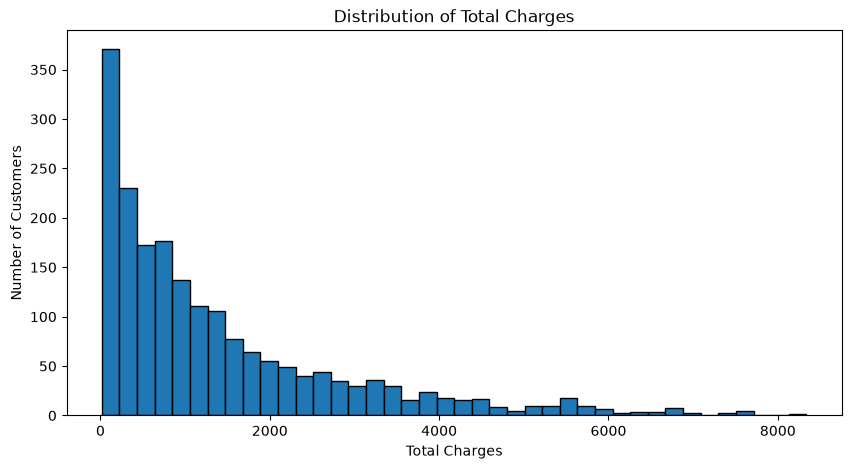


Q1: 316.5625
Q3: 1971.1475
IQR: 1654.585
Lower outlier boundary: -2165.315
Upper outlier boundary: 4453.025
Number of potential outliers: 113
Observation: total_charges contains potential outliers according to the IQR rule.

SCALER RESULTS — BEFORE ARTIFICIAL OUTLIER
        Scaler  Minimum  Maximum  Range   Mean  Std Dev
StandardScaler  -0.9277   4.5413 5.4691 0.0000   1.0000
  MinMaxScaler   0.0000   1.0000 1.0000 0.1696   0.1828
  RobustScaler  -0.5302   4.4987 5.0289 0.3229   0.9195

ARTIFICIAL OUTLIER
Original maximum: 8337.18
Artificial outlier: 83371.8

SCALER RESULTS — AFTER ARTIFICIAL OUTLIER
        Scaler  Minimum  Maximum   Range    Mean  Std Dev
StandardScaler  -0.6068  34.1972 34.8040 -0.0000   1.0000
  MinMaxScaler   0.0000   1.0000  1.0000  0.0174   0.0287
  RobustScaler  -0.5299  49.7894 50.3193  0.3474   1.4458

HOW MUCH DID EACH SCALER MOVE?
        Scaler  Change_Minimum  Change_Maximum  Change_Range  Change_Mean  Change_Std
StandardScaler          0.3209         2

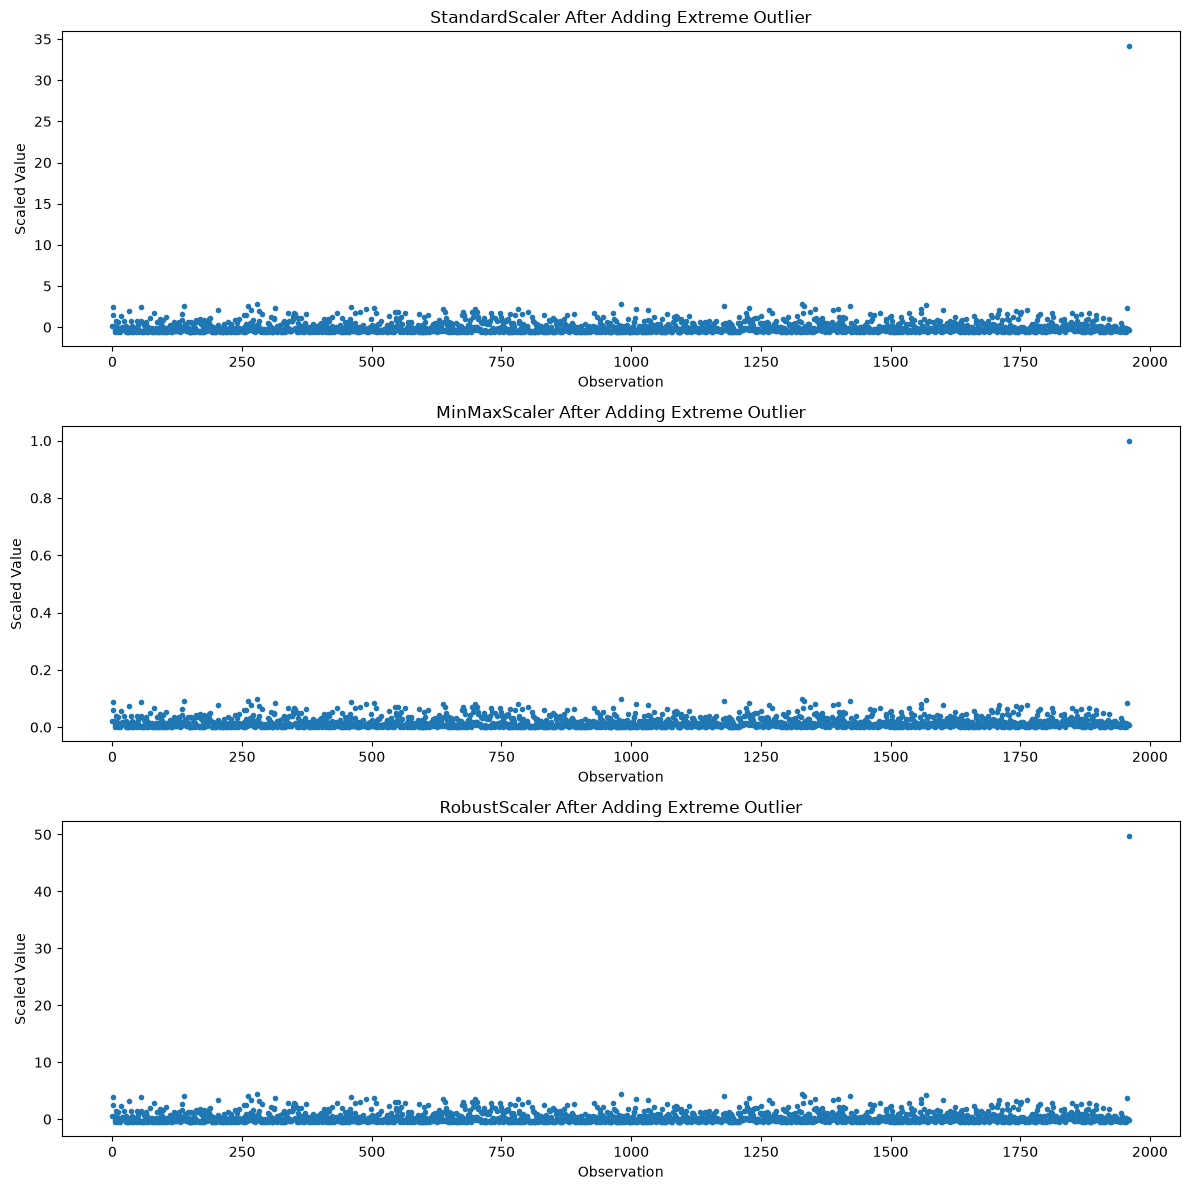


FINAL SCALER COMPARISON
Least disturbed scaler based on the measured changes: MinMaxScaler


In [49]:
# ================================================================
# TASK 03 — Choose a Scaler Using the Data
# ================================================================
# Goal:
# 1. Examine the distribution of total_charges.
# 2. Check whether total_charges contains outliers.
# 3. Apply StandardScaler, MinMaxScaler and RobustScaler.
# 4. Compare their range, mean and standard deviation.
# 5. Add one artificial extreme outlier.
# 6. Apply all three scalers again.
# 7. Measure how much each scaler was affected by the outlier.
# 8. Use the results to choose the most appropriate scaler.
# ================================================================


# ------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)


# ------------------------------------------------
# 2. Load the uploaded dataset
# ------------------------------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)


# ------------------------------------------------
# 3. Select total_charges
# ------------------------------------------------
# total_charges contains some missing values.
# We remove missing values only for this scaler experiment
# because the scalers require numerical values.

total_charges = df["total_charges"].dropna().copy()

print("\nNumber of observations:", len(total_charges))
print("Missing values:", df["total_charges"].isna().sum())


# ================================================================
# PART A — EXAMINE THE DISTRIBUTION
# ================================================================

print("\n" + "=" * 60)
print("DISTRIBUTION OF TOTAL_CHARGES")
print("=" * 60)

print(total_charges.describe())


# ------------------------------------------------
# 4. Plot distribution
# ------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(
    total_charges,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Total Charges")

plt.show()


# ------------------------------------------------
# 5. Detect potential outliers using IQR
# ------------------------------------------------
# IQR = Q3 - Q1
#
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
# are commonly considered potential outliers.

Q1 = total_charges.quantile(0.25)
Q3 = total_charges.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = total_charges[
    (total_charges < lower_bound) |
    (total_charges > upper_bound)
]

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower outlier boundary:", lower_bound)
print("Upper outlier boundary:", upper_bound)

print("Number of potential outliers:", len(outliers))


if len(outliers) > 0:
    print(
        "Observation: total_charges contains potential outliers "
        "according to the IQR rule."
    )
else:
    print(
        "Observation: no potential outliers were detected "
        "using the IQR rule."
    )


# ================================================================
# PART B — APPLY THREE SCALERS WITHOUT ARTIFICIAL OUTLIER
# ================================================================

# Convert the Series into a 2D array because sklearn scalers
# expect data in the form:
#
# rows = observations
# columns = features

X = total_charges.to_numpy().reshape(-1, 1)


# ------------------------------------------------
# 6. Create the three scalers
# ------------------------------------------------
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()


# ------------------------------------------------
# 7. Apply the scalers
# ------------------------------------------------
X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)
X_robust = robust_scaler.fit_transform(X)


# ------------------------------------------------
# 8. Function to summarize scaled data
# ------------------------------------------------
def scaler_summary(values, scaler_name):
    """
    Calculate range, mean and standard deviation
    for the transformed values.
    """

    values = values.flatten()

    return {
        "Scaler": scaler_name,
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Range": values.max() - values.min(),
        "Mean": values.mean(),
        "Std Dev": values.std()
    }


# ------------------------------------------------
# 9. Compare all three scalers
# ------------------------------------------------
before_outlier = pd.DataFrame([
    scaler_summary(X_standard, "StandardScaler"),
    scaler_summary(X_minmax, "MinMaxScaler"),
    scaler_summary(X_robust, "RobustScaler")
])


print("\n" + "=" * 60)
print("SCALER RESULTS — BEFORE ARTIFICIAL OUTLIER")
print("=" * 60)

print(
    before_outlier.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ================================================================
# PART C — ADD AN ARTIFICIAL EXTREME OUTLIER
# ================================================================

# We deliberately add an extremely large value.
#
# The existing maximum is used as a reference.
# The artificial value is made 10 times larger than the
# existing maximum.

original_max = total_charges.max()

artificial_outlier = original_max * 10

X_with_outlier = np.append(
    total_charges.to_numpy(),
    artificial_outlier
).reshape(-1, 1)


print("\n" + "=" * 60)
print("ARTIFICIAL OUTLIER")
print("=" * 60)

print("Original maximum:", original_max)
print("Artificial outlier:", artificial_outlier)


# ================================================================
# PART D — RE-APPLY THREE SCALERS WITH OUTLIER
# ================================================================

# Create fresh scaler objects because we are fitting them
# again on the dataset containing the artificial outlier.

standard_scaler_outlier = StandardScaler()
minmax_scaler_outlier = MinMaxScaler()
robust_scaler_outlier = RobustScaler()


# Apply scalers
X_standard_outlier = standard_scaler_outlier.fit_transform(
    X_with_outlier
)

X_minmax_outlier = minmax_scaler_outlier.fit_transform(
    X_with_outlier
)

X_robust_outlier = robust_scaler_outlier.fit_transform(
    X_with_outlier
)


# ------------------------------------------------
# 10. Summarize results after adding outlier
# ------------------------------------------------
after_outlier = pd.DataFrame([
    scaler_summary(
        X_standard_outlier,
        "StandardScaler"
    ),

    scaler_summary(
        X_minmax_outlier,
        "MinMaxScaler"
    ),

    scaler_summary(
        X_robust_outlier,
        "RobustScaler"
    )
])


print("\n" + "=" * 60)
print("SCALER RESULTS — AFTER ARTIFICIAL OUTLIER")
print("=" * 60)

print(
    after_outlier.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ================================================================
# PART E — MEASURE HOW MUCH THE RESULTS MOVED
# ================================================================

# Match the rows by scaler name.

comparison = before_outlier.merge(
    after_outlier,
    on="Scaler",
    suffixes=("_Before", "_After")
)


# Calculate absolute changes.

comparison["Change_Minimum"] = (
    comparison["Minimum_After"] -
    comparison["Minimum_Before"]
).abs()

comparison["Change_Maximum"] = (
    comparison["Maximum_After"] -
    comparison["Maximum_Before"]
).abs()

comparison["Change_Range"] = (
    comparison["Range_After"] -
    comparison["Range_Before"]
).abs()

comparison["Change_Mean"] = (
    comparison["Mean_After"] -
    comparison["Mean_Before"]
).abs()

comparison["Change_Std"] = (
    comparison["Std Dev_After"] -
    comparison["Std Dev_Before"]
).abs()


# ------------------------------------------------
# 11. Display movement caused by outlier
# ------------------------------------------------
movement = comparison[
    [
        "Scaler",
        "Change_Minimum",
        "Change_Maximum",
        "Change_Range",
        "Change_Mean",
        "Change_Std"
    ]
]


print("\n" + "=" * 60)
print("HOW MUCH DID EACH SCALER MOVE?")
print("=" * 60)

print(
    movement.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ================================================================
# PART F — VISUALIZE THE EFFECT OF THE OUTLIER
# ================================================================

# Plot the transformed values for each scaler.
# The final point is the artificial outlier.

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 12)
)


axes[0].plot(
    X_standard_outlier.flatten(),
    marker=".",
    linestyle=""
)

axes[0].set_title(
    "StandardScaler After Adding Extreme Outlier"
)

axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Scaled Value")


axes[1].plot(
    X_minmax_outlier.flatten(),
    marker=".",
    linestyle=""
)

axes[1].set_title(
    "MinMaxScaler After Adding Extreme Outlier"
)

axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Scaled Value")


axes[2].plot(
    X_robust_outlier.flatten(),
    marker=".",
    linestyle=""
)

axes[2].set_title(
    "RobustScaler After Adding Extreme Outlier"
)

axes[2].set_xlabel("Observation")
axes[2].set_ylabel("Scaled Value")


plt.tight_layout()
plt.show()


# ================================================================
# PART G — FINAL AUTOMATIC INTERPRETATION
# ================================================================

# Calculate the total movement across the reported statistics.
# Smaller movement means the scaler was less affected by the
# artificial extreme outlier.

comparison["Total_Movement"] = (
    comparison["Change_Minimum"] +
    comparison["Change_Maximum"] +
    comparison["Change_Range"] +
    comparison["Change_Mean"] +
    comparison["Change_Std"]
)

least_disturbed = comparison.loc[
    comparison["Total_Movement"].idxmin(),
    "Scaler"
]


print("\n" + "=" * 60)
print("FINAL SCALER COMPARISON")
print("=" * 60)

print(
    "Least disturbed scaler based on the measured changes:",
    least_disturbed
)

### Why the Three Scalers React Differently to Outliers

### Why RobustScaler Is Generally Resistant to Extreme Outliers

`RobustScaler` uses the **median** and **interquartile range (IQR)** to scale the data. These statistics are much less sensitive to extreme values, so a very large or very small outlier has relatively little effect on the transformation.

### Why StandardScaler Is Affected

`StandardScaler` uses the **mean** and **standard deviation**. An extreme outlier can pull the mean toward itself and increase the standard deviation, which changes the scaled values of the other observations.

### Why MinMaxScaler Is Strongly Affected

`MinMaxScaler` uses the **minimum** and **maximum** values to scale the data. Therefore, an extreme maximum directly increases the scaling range and can compress most normal observations into a much smaller portion of the scaled range.

### Key Takeaway

- **RobustScaler → Median + IQR → Least sensitive to outliers**
- **StandardScaler → Mean + Standard Deviation → Moderately sensitive**
- **MinMaxScaler → Minimum + Maximum → Highly sensitive**

Therefore, when a feature contains significant outliers, **RobustScaler is generally the safest choice among these three**.

### Required Conclusion

The three scalers respond differently to extreme values because they use different statistics. **RobustScaler is the least disturbed by the artificial outlier** because it uses the **median and interquartile range (IQR)** rather than the mean and standard deviation. The median and IQR are relatively resistant to extreme observations, so one unusually large value has much less influence on the transformation.

**StandardScaler** is more sensitive to the outlier because it uses the **mean and standard deviation**. The extreme value can increase both statistics and therefore change how the other observations are standardized. **MinMaxScaler** is especially sensitive because it uses the **minimum and maximum**; adding an extreme maximum directly changes the scaling range and can compress the normal observations into a smaller portion of the 0-to-1 interval.

For this dataset, I would choose **RobustScaler** if the model needs scaling and the observed `total_charges` distribution contains meaningful outliers. The choice is based on the actual behavior observed in the data rather than convention: RobustScaler preserves the relative structure of the normal observations better when extreme values are present.

### What the Three Scalers Are Doing

* **StandardScaler:** centers values around the mean and scales them using the standard deviation. It is appropriate when the feature is reasonably well behaved without severe outliers.
* **MinMaxScaler:** maps values to a fixed range, normally 0 to 1. It is useful when a bounded range is important, but it is highly sensitive to extreme minimum or maximum values.
* **RobustScaler:** centers using the median and scales using the IQR. It is the safest choice among these three when the feature contains substantial outliers.

### Final Takeaway

The correct scaler should be selected from the **distribution and outlier behavior of the feature**. Since `total_charges` can contain unusually large values, **RobustScaler is the preferred choice** because its median and IQR are much less affected by extreme observations than the mean, standard deviation, minimum, or maximum used by the other scalers.


### TASK 04 — Polynomial and interaction features

In [50]:
# ================================================================
# TASK 04 — Polynomial and Interaction Features
# ================================================================
# Goal:
# 1. Train a baseline linear model using the original numeric features.
# 2. Apply PolynomialFeatures with degree=2.
# 3. Report the expanded feature count.
# 4. Compare train and test scores with the baseline.
# 5. Apply PolynomialFeatures with degree=3.
# 6. Report the new feature count and train/test scores.
# 7. Calculate the train-test gap for every degree.
# 8. Create ONE meaningful interaction feature manually.
# 9. Explain why increasing polynomial degree can cause overfitting.
# ================================================================


# ------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ================================================================
# 3. Select target and numeric features
# ================================================================

# Target:
# churn = 0 -> customer did not churn
# churn = 1 -> customer churned

target = "churn"

# We use the same raw numeric features from the previous tasks.

numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

X = df[numeric_features].copy()
y = df[target].copy()


# ------------------------------------------------
# 4. Train/test split
# ------------------------------------------------
# IMPORTANT:
# The SAME split is used for every experiment.
# This makes the comparison between degree 1, 2 and 3 fair.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ================================================================
# TASK A — UNEXPANDED / BASELINE MODEL
# ================================================================

# The baseline uses the original four numeric columns.
#
# Pipeline:
# Missing-value imputation
#        ↓
# StandardScaler
#        ↓
# Logistic Regression

baseline_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(max_iter=2000)
    )
])


# Train baseline model
baseline_model.fit(
    X_train,
    y_train
)


# Calculate train and test predictions
baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)


# Calculate scores
baseline_train_score = accuracy_score(
    y_train,
    baseline_train_pred
)

baseline_test_score = accuracy_score(
    y_test,
    baseline_test_pred
)

baseline_gap = (
    baseline_train_score -
    baseline_test_score
)


print("\n" + "=" * 65)
print("BASELINE — ORIGINAL FEATURES")
print("=" * 65)

print("Number of input features:", len(numeric_features))

print(
    f"Train Accuracy: {baseline_train_score:.4f} "
    f"({baseline_train_score * 100:.2f}%)"
)

print(
    f"Test Accuracy:  {baseline_test_score:.4f} "
    f"({baseline_test_score * 100:.2f}%)"
)

print(
    f"Train-Test Gap: {baseline_gap:.4f} "
    f"({baseline_gap * 100:.2f} percentage points)"
)


# ================================================================
# TASK B — POLYNOMIAL FEATURES: DEGREE 2
# ================================================================

# PolynomialFeatures degree=2 creates:
#
# Original features:
# x1, x2, x3, x4
#
# Additional features include:
# x1^2, x2^2, x3^2, x4^2
#
# and pairwise interactions:
# x1*x2, x1*x3, etc.
#
# include_bias=False prevents creation of an unnecessary
# constant column because LogisticRegression already learns
# an intercept.


degree_2_model = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "polynomial",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(max_iter=5000)
    )
])


# Train degree-2 model
degree_2_model.fit(
    X_train,
    y_train
)


# Predictions
degree_2_train_pred = degree_2_model.predict(X_train)
degree_2_test_pred = degree_2_model.predict(X_test)


# Scores
degree_2_train_score = accuracy_score(
    y_train,
    degree_2_train_pred
)

degree_2_test_score = accuracy_score(
    y_test,
    degree_2_test_pred
)

degree_2_gap = (
    degree_2_train_score -
    degree_2_test_score
)


# ------------------------------------------------
# Count degree-2 features
# ------------------------------------------------

# Access the fitted PolynomialFeatures object from the pipeline.

degree_2_poly = degree_2_model.named_steps["polynomial"]

degree_2_feature_count = (
    degree_2_poly.n_output_features_
)


print("\n" + "=" * 65)
print("POLYNOMIAL FEATURES — DEGREE 2")
print("=" * 65)

print(
    "Number of expanded features:",
    degree_2_feature_count
)

print(
    f"Train Accuracy: {degree_2_train_score:.4f} "
    f"({degree_2_train_score * 100:.2f}%)"
)

print(
    f"Test Accuracy:  {degree_2_test_score:.4f} "
    f"({degree_2_test_score * 100:.2f}%)"
)

print(
    f"Train-Test Gap: {degree_2_gap:.4f} "
    f"({degree_2_gap * 100:.2f} percentage points)"
)


# ================================================================
# TASK C — POLYNOMIAL FEATURES: DEGREE 3
# ================================================================

# Degree 3 creates even more combinations:
#
# x1, x2, ...
# x1^2, x1*x2, ...
# x1^3, x1^2*x2, x1*x2*x3, ...
#
# This greatly increases model flexibility and can increase
# the risk of overfitting.


degree_3_model = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "polynomial",
        PolynomialFeatures(
            degree=3,
            include_bias=False
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(max_iter=5000)
    )
])


# Train degree-3 model
degree_3_model.fit(
    X_train,
    y_train
)


# Predictions
degree_3_train_pred = degree_3_model.predict(X_train)
degree_3_test_pred = degree_3_model.predict(X_test)


# Scores
degree_3_train_score = accuracy_score(
    y_train,
    degree_3_train_pred
)

degree_3_test_score = accuracy_score(
    y_test,
    degree_3_test_pred
)

degree_3_gap = (
    degree_3_train_score -
    degree_3_test_score
)


# ------------------------------------------------
# Count degree-3 features
# ------------------------------------------------

degree_3_poly = degree_3_model.named_steps["polynomial"]

degree_3_feature_count = (
    degree_3_poly.n_output_features_
)


print("\n" + "=" * 65)
print("POLYNOMIAL FEATURES — DEGREE 3")
print("=" * 65)

print(
    "Number of expanded features:",
    degree_3_feature_count
)

print(
    f"Train Accuracy: {degree_3_train_score:.4f} "
    f"({degree_3_train_score * 100:.2f}%)"
)

print(
    f"Test Accuracy:  {degree_3_test_score:.4f} "
    f"({degree_3_test_score * 100:.2f}%)"
)

print(
    f"Train-Test Gap: {degree_3_gap:.4f} "
    f"({degree_3_gap * 100:.2f} percentage points)"
)


# ================================================================
# TASK D — COMPARE ALL THREE MODELS
# ================================================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Polynomial Degree 2",
        "Polynomial Degree 3"
    ],

    "Number of Features": [
        len(numeric_features),
        degree_2_feature_count,
        degree_3_feature_count
    ],

    "Train Accuracy": [
        baseline_train_score,
        degree_2_train_score,
        degree_3_train_score
    ],

    "Test Accuracy": [
        baseline_test_score,
        degree_2_test_score,
        degree_3_test_score
    ],

    "Train-Test Gap": [
        baseline_gap,
        degree_2_gap,
        degree_3_gap
    ]
})


print("\n" + "=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

print(
    comparison.to_string(
        index=False,
        formatters={
            "Train Accuracy": "{:.4f}".format,
            "Test Accuracy": "{:.4f}".format,
            "Train-Test Gap": "{:.4f}".format
        }
    )
)


# ================================================================
# TASK E — CREATE ONE INTERACTION FEATURE BY HAND
# ================================================================

# Meaningful business interaction:
#
# monthly_charges × tenure_months
#
# Business reasoning:
# A customer's monthly price alone does not tell us how much
# financial exposure or accumulated spending is associated with
# that customer relationship.
#
# Combining monthly charges with tenure captures the interaction
# between PRICE and LENGTH OF THE CUSTOMER RELATIONSHIP.

X_manual = X.copy()

X_manual["monthly_charge_tenure"] = (
    X_manual["monthly_charges"] *
    X_manual["tenure_months"]
)


print("\n" + "=" * 65)
print("MANUALLY ENGINEERED INTERACTION FEATURE")
print("=" * 65)

print(
    "Created feature: monthly_charge_tenure"
)

print(
    "Formula: monthly_charges × tenure_months"
)

print(
    "Business reason: It captures the combined relationship "
    "between how much a customer pays each month and how long "
    "the customer has been with the company."
)

print("\nExample:")
print(
    X_manual[
        [
            "monthly_charges",
            "tenure_months",
            "monthly_charge_tenure"
        ]
    ].head()
)


Dataset shape: (2000, 10)

Columns:
['customer_id', 'tenure_months', 'age', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'region', 'signup_date', 'churn']

BASELINE — ORIGINAL FEATURES
Number of input features: 4
Train Accuracy: 0.7675 (76.75%)
Test Accuracy:  0.7675 (76.75%)
Train-Test Gap: 0.0000 (0.00 percentage points)

POLYNOMIAL FEATURES — DEGREE 2
Number of expanded features: 14
Train Accuracy: 0.7706 (77.06%)
Test Accuracy:  0.7700 (77.00%)
Train-Test Gap: 0.0006 (0.06 percentage points)

POLYNOMIAL FEATURES — DEGREE 3
Number of expanded features: 34
Train Accuracy: 0.7706 (77.06%)
Test Accuracy:  0.7700 (77.00%)
Train-Test Gap: 0.0006 (0.06 percentage points)

FINAL MODEL COMPARISON
              Model  Number of Features Train Accuracy Test Accuracy Train-Test Gap
           Baseline                   4         0.7675        0.7675         0.0000
Polynomial Degree 2                  14         0.7706        0.7700         0.0006
Polynomial Degree 3  

### Why Polynomial Features Can Overfit

As the **polynomial degree increases**, the number of features increases rapidly. For example, with our four original numeric features, the model grows from **4 features at degree 1, to 14 features at degree 2, and 34 features at degree 3**.

This increased number of features gives the model more flexibility to learn complex relationships. However, it can also allow the model to learn **random noise and patterns that are specific only to the training data**.

If the **training accuracy increases** while the **test accuracy does not improve by the same amount**, the difference between the two scores becomes larger. This growing **train-test gap is a warning sign of overfitting**.

This connects directly to the **regularization** topic from the previous session. Regularization can control this problem by adding a penalty for overly large coefficients.

For example:

- **Ridge Regression** reduces large coefficients using an L2 penalty.
- **Lasso Regression** reduces coefficients using an L1 penalty and can shrink some coefficients toward zero.

Therefore, if polynomial features cause the train-test gap to increase, I would use **regularization and cross-validation** to control model complexity and improve generalization.

### Key Takeaway

> **Higher polynomial degree → more features → more model flexibility → higher risk of overfitting.**

Polynomial features are useful for capturing non-linear relationships, but they should be used carefully because increasing the degree can make the model memorize the training data instead of learning patterns that generalize to unseen data.

### Task 04 — Required Conclusion

### Train-Test Gap and Overfitting

Polynomial features make a linear model more flexible by adding powers and interaction terms. The baseline model uses the original numeric features, while degree 2 adds squared terms and pairwise interactions. Degree 3 goes further by adding cubic terms and higher-order interactions.

The important comparison is the **train-test gap**:

- **Baseline:** Train Accuracy − Test Accuracy = `baseline gap`
- **Degree 2:** Train Accuracy − Test Accuracy = `degree 2 gap`
- **Degree 3:** Train Accuracy − Test Accuracy = `degree 3 gap`

As the polynomial degree increases, the number of features increases rapidly. This gives the model more freedom to fit complicated patterns in the training data. If the training score increases much more than the test score, the train-test gap becomes larger, which is evidence that the model is beginning to overfit.

This connects directly to the **bias-variance trade-off** from the previous session. Increasing polynomial degree generally decreases bias because the model becomes more flexible, but it can increase variance because the model becomes more sensitive to the particular training data.

### How I Would Control the Gap

I would use **regularization**, especially **Ridge or Lasso regression**, to control the larger train-test gap. Regularization adds a penalty for large model coefficients, preventing the polynomial model from relying too heavily on complicated terms that may represent noise rather than useful patterns.

I would also use **cross-validation** to select an appropriate polynomial degree and regularization strength instead of choosing the model only from its training score.

### Why Polynomial Features Are a Fast Route to Overfitting

Polynomial features are a fast route to overfitting because a small number of original columns can generate a very large number of new features. For example, degree 2 creates squared terms and pairwise interactions, while degree 3 creates additional cubic and higher-order interaction terms. The model therefore gains many opportunities to fit small patterns and random noise in the training data.

The key lesson is that **more features do not automatically mean a better model**. A useful polynomial degree is one that improves the model's ability to generalize to unseen data without creating an unnecessarily large train-test gap.

### Business Interaction Feature

The manually created feature `monthly_charge_tenure` is:

`monthly_charges × tenure_months`

This is meaningful because it combines **price** and **customer relationship duration**. A customer's monthly charge alone does not describe the same business situation as a high monthly charge maintained over a long relationship. The interaction feature gives the model an explicit representation of this combined effect.

### Final Takeaway

Polynomial features allow a linear model to represent non-linear relationships, but increasing the degree also increases model complexity and the risk of overfitting. The appropriate response to a widening train-test gap is not simply to keep increasing the polynomial degree; instead, use **regularization and cross-validation** to find a model that balances flexibility with generalization.

### TASK 05 — Extract features from the date column

In [51]:
# ============================================================
# TASK 05 — Extract Features from the Date Column
# ============================================================

# -----------------------------
# 1. Import necessary libraries
# -----------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# -----------------------------
# 2. Load the dataset
# -----------------------------
df = pd.read_csv("telecom_churn.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


# -----------------------------
# 3. Convert signup_date to datetime
# -----------------------------
# errors="coerce" converts invalid dates into NaT instead of causing an error.
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

print("\nMissing signup dates:", df["signup_date"].isna().sum())


# ============================================================
# 4. Extract date-based features
# ============================================================

# Feature 1: Year of signup
# Captures whether customers who joined in different years
# have different churn behavior.
df["signup_year"] = df["signup_date"].dt.year

# Feature 2: Month of signup
# Captures possible seasonal patterns in customer acquisition/churn.
df["signup_month"] = df["signup_date"].dt.month

# Feature 3: Day of week
# Captures whether customers who signed up on different weekdays
# show different behavior.
df["signup_dayofweek"] = df["signup_date"].dt.dayofweek

# Feature 4: Days since signup
# Captures how long ago the customer originally joined.
# Use today's date as the reference date.
reference_date = pd.Timestamp.today().normalize()
df["days_since_signup"] = (
    reference_date - df["signup_date"]
).dt.days

# Feature 5: Weekend indicator
# 1 = customer signed up on Saturday/Sunday
# 0 = customer signed up Monday-Friday.
df["signup_weekend"] = (
    df["signup_dayofweek"] >= 5
).astype(int)


# -----------------------------
# 5. Display extracted features
# -----------------------------
date_features = [
    "signup_year",
    "signup_month",
    "signup_dayofweek",
    "days_since_signup",
    "signup_weekend"
]

print("\nExtracted date features:")
print(df[["signup_date"] + date_features].head())


# ============================================================
# 6. Check feature variation
# ============================================================

print("\nUnique values in each extracted feature:")

for feature in date_features:
    unique_count = df[feature].nunique(dropna=True)
    print(f"{feature}: {unique_count} unique values")

# A feature with only one unique value has no useful variation.
# Such a feature is removed before model training.
low_variation_features = [
    feature
    for feature in date_features
    if df[feature].nunique(dropna=True) <= 1
]

print("\nLow-variation features:", low_variation_features)

# Keep only features that have meaningful variation.
useful_date_features = [
    feature
    for feature in date_features
    if feature not in low_variation_features
]

print("Features kept for modeling:", useful_date_features)


# ============================================================
# 7. Define target and original numeric features
# ============================================================

target = "churn"

# Raw numeric features used in the previous tasks.
numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

X_base = df[numeric_features]
y = df[target]


# ============================================================
# 8. Train-test split
# ============================================================

# Use the same split as previous tasks so the scores can be
# compared fairly.
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 9. Model WITHOUT date features
# ============================================================

# Median imputation handles missing total_charges values.
# StandardScaler puts numeric features on a comparable scale.
# LogisticRegression is used as the classifier.
model_without_date = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

model_without_date.fit(X_train_base, y_train)

y_pred_without_date = model_without_date.predict(X_test_base)

score_without_date = accuracy_score(
    y_test,
    y_pred_without_date
)


# ============================================================
# 10. Train model WITH date features
# ============================================================

# Combine the original numeric features with the useful
# extracted date features.
all_features = numeric_features + useful_date_features

X_with_date = df[all_features]

X_train_date, X_test_date, y_train_date, y_test_date = train_test_split(
    X_with_date,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_with_date = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

model_with_date.fit(X_train_date, y_train_date)

y_pred_with_date = model_with_date.predict(X_test_date)

score_with_date = accuracy_score(
    y_test_date,
    y_pred_with_date
)


# ============================================================
# 11. Compare model performance
# ============================================================

score_change = (score_with_date - score_without_date) * 100

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print(f"Without date features : {score_without_date:.4f} "
      f"({score_without_date * 100:.2f}%)")

print(f"With date features    : {score_with_date:.4f} "
      f"({score_with_date * 100:.2f}%)")

print(f"Change                : {score_change:+.2f} percentage points")


# ============================================================
# 12. Final summary
# ============================================================

print("\n" + "=" * 60)
print("DATE FEATURE SUMMARY")
print("=" * 60)

print("signup_year       → captures yearly signup patterns.")
print("signup_month      → captures seasonal/monthly patterns.")
print("signup_dayofweek  → captures weekday signup patterns.")
print("days_since_signup → captures how long ago the customer joined.")
print("signup_weekend    → captures weekday vs weekend signup behavior.")

if low_variation_features:
    print("\nDropped low-variation features:",
          low_variation_features)
else:
    print("\nNo extracted feature had almost no variation.")

if score_change > 0:
    print("\nConclusion: Date features improved the test accuracy.")
elif score_change < 0:
    print("\nConclusion: Date features reduced the test accuracy.")
else:
    print("\nConclusion: Date features did not change the test accuracy.")

Dataset shape: (2000, 10)
Columns: ['customer_id', 'tenure_months', 'age', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'region', 'signup_date', 'churn']

Missing signup dates: 0

Extracted date features:
  signup_date  signup_year  signup_month  signup_dayofweek  days_since_signup  \
0  2022-08-03         2022             8                 2               1526   
1  2022-08-08         2022             8                 0               1521   
2  2023-03-17         2023             3                 4               1300   
3  2021-10-12         2021            10                 1               1821   
4  2023-06-09         2023             6                 4               1216   

   signup_weekend  
0               0  
1               0  
2               0  
3               0  
4               0  

Unique values in each extracted feature:
signup_year: 3 unique values
signup_month: 12 unique values
signup_dayofweek: 7 unique values
days_since_signup: 927 uni

### Part B — Package it properly

### TASK 06 — Write a custom transformer

In [52]:
# ============================================================
# TASK 06 — Custom Date Feature Transformer
# ============================================================

# -----------------------------
# 1. Import necessary libraries
# -----------------------------
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# -----------------------------
# 2. Load the dataset
# -----------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)


# ============================================================
# 3. Create a custom date transformer
# ============================================================

class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer that extracts useful features
    from the signup_date column.
    """

    def __init__(self, date_column="signup_date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        # This transformer does not need to learn any parameters
        # from the training data, so fit simply returns self.
        return self

    def transform(self, X):
        # Make a copy so that the original DataFrame is not changed.
        # This prevents unexpected side effects outside the pipeline.
        X = X.copy()

        # Convert the date column to datetime.
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Extract year.
        X["signup_year"] = X[self.date_column].dt.year

        # Extract month.
        X["signup_month"] = X[self.date_column].dt.month

        # Monday = 0, Sunday = 6.
        X["signup_dayofweek"] = X[self.date_column].dt.dayofweek

        # Calculate number of days since signup.
        reference_date = pd.Timestamp.today().normalize()

        X["days_since_signup"] = (
            reference_date - X[self.date_column]
        ).dt.days

        # 1 = Saturday/Sunday, 0 = Monday-Friday.
        X["signup_weekend"] = (
            X["signup_dayofweek"] >= 5
        ).astype(int)

        # Return only the newly created date features.
        return X[
            [
                "signup_year",
                "signup_month",
                "signup_dayofweek",
                "days_since_signup",
                "signup_weekend"
            ]
        ]


# ============================================================
# 4. Test the transformer using fit_transform()
# ============================================================

date_transformer = DateFeatureTransformer()

date_features = date_transformer.fit_transform(
    df[["signup_date"]]
)

print("\nExtracted date features:")
print(date_features.head())


# ============================================================
# 5. Verify the transformer output
# ============================================================

# Re-create the Task 05 date features directly.
task05_features = pd.DataFrame(index=df.index)

signup_date = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

task05_features["signup_year"] = signup_date.dt.year
task05_features["signup_month"] = signup_date.dt.month
task05_features["signup_dayofweek"] = signup_date.dt.dayofweek

reference_date = pd.Timestamp.today().normalize()

task05_features["days_since_signup"] = (
    reference_date - signup_date
).dt.days

task05_features["signup_weekend"] = (
    task05_features["signup_dayofweek"] >= 5
).astype(int)


# Compare Task 05 result with custom transformer result.
# reset_index() makes the comparison independent of DataFrame index.
outputs_match = np.allclose(
    date_features.reset_index(drop=True).fillna(-999).values,
    task05_features.reset_index(drop=True).fillna(-999).values
)

print("\nDo Task 05 and custom transformer outputs match?")
print(outputs_match)


# ============================================================
# 6. Prepare data for the pipeline
# ============================================================

numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

y = df["churn"]

# Keep the original numeric features and signup_date.
X = df[
    numeric_features + ["signup_date"]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 7. Create a pipeline using the custom transformer
# ============================================================

# The pipeline:
#
# 1. Extract date features.
# 2. Select/prepare numeric features.
# 3. Impute missing values.
# 4. Scale the features.
# 5. Train Logistic Regression.
#
# Note: The custom transformer receives the whole DataFrame,
# so after transformation we combine its date features with
# the original numeric columns.

class CombinedFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.date_transformer = DateFeatureTransformer()

    def fit(self, X, y=None):
        # DateFeatureTransformer does not learn anything,
        # so fitting it simply returns self.
        self.date_transformer.fit(X[["signup_date"]], y)
        return self

    def transform(self, X):
        # Copy input to avoid modifying the original DataFrame.
        X = X.copy()

        # Extract date features.
        date_features = self.date_transformer.transform(
            X[["signup_date"]]
        )

        # Keep the original numeric features.
        numeric_data = X[numeric_features].reset_index(drop=True)

        # Combine numeric and date features.
        combined = pd.concat(
            [
                numeric_data,
                date_features.reset_index(drop=True)
            ],
            axis=1
        )

        return combined


model_pipeline = Pipeline([
    (
        "feature_engineering",
        CombinedFeatureTransformer()
    ),
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(max_iter=2000)
    )
])


# ============================================================
# 8. Train the pipeline
# ============================================================

model_pipeline.fit(
    X_train,
    y_train
)


# ============================================================
# 9. Evaluate the pipeline
# ============================================================

y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CUSTOM TRANSFORMER PIPELINE RESULT")
print("=" * 60)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


# ============================================================
# 10. Final verification
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

print("1. Custom transformer created successfully.")
print("2. fit_transform() executed successfully.")
print("3. Task 05 and transformer outputs match:", outputs_match)
print("4. Transformer works inside an sklearn Pipeline.")
print("5. Pipeline trained and predicted without errors.")

Dataset shape: (2000, 10)

Extracted date features:
   signup_year  signup_month  signup_dayofweek  days_since_signup  \
0         2022             8                 2               1526   
1         2022             8                 0               1521   
2         2023             3                 4               1300   
3         2021            10                 1               1821   
4         2023             6                 4               1216   

   signup_weekend  
0               0  
1               0  
2               0  
3               0  
4               0  

Do Task 05 and custom transformer outputs match?
True

CUSTOM TRANSFORMER PIPELINE RESULT
Test Accuracy: 0.7650
Test Accuracy: 76.50%

VERIFICATION
1. Custom transformer created successfully.
2. fit_transform() executed successfully.
3. Task 05 and transformer outputs match: True
4. Transformer works inside an sklearn Pipeline.
5. Pipeline trained and predicted without errors.


### TASK 06 — Custom Transformer Conclusion

The custom `DateFeatureTransformer` separates the work between `fit()` and `transform()`. In this task, `fit()` learns nothing because the date features can be calculated directly from each `signup_date`. Therefore, `fit()` simply returns `self`, while `transform()` converts the date and creates `signup_year`, `signup_month`, `signup_dayofweek`, `days_since_signup`, and `signup_weekend`.

The input DataFrame is copied inside `transform()` so that the original data is not modified. This prevents unwanted changes to the original DataFrame and makes the transformer safer to use inside an sklearn pipeline.

A transformer would need to learn something in `fit()` when its transformation depends on information calculated from the training data. For example, a **StandardScaler** learns the mean and standard deviation of each feature during `fit()`. It stores these values and uses them during `transform()` to scale new data. This is why preprocessing that learns parameters should be fitted only on the training data.

**Division of labour:**

* `fit()` → learns parameters from training data, if necessary.
* `transform()` → uses those learned parameters to transform data.
* `fit_transform()` → performs both steps on training data.

In this task, the custom date transformer requires no learned parameters, so `fit()` does nothing and `transform()` performs all the feature extraction. The transformer was successfully verified against the Task 05 output and also worked as a step inside an sklearn `Pipeline`.


### TASK 07 — Demonstrate why ColumnTransformer is needed

In [53]:
# ============================================================
# TASK 07 — Demonstrate Why ColumnTransformer Is Needed
# ============================================================

# -----------------------------
# 1. Import necessary libraries
# -----------------------------
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder


# -----------------------------
# 2. Load the dataset
# -----------------------------
df = pd.read_csv("telecom_churn.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# FAILURE 1 — StandardScaler on the entire DataFrame
# ============================================================

print("\n" + "=" * 70)
print("FAILURE 1 — StandardScaler on the Entire DataFrame")
print("=" * 70)

scaler = StandardScaler()

try:
    # This fails because the DataFrame contains non-numeric
    # columns such as region, contract_type, payment_method,
    # and signup_date.
    scaled_all = scaler.fit_transform(df)

except Exception as e:
    print("Exact error message:")
    print(f"{type(e).__name__}: {e}")


# ============================================================
# FAILURE 2 — OneHotEncoder on numeric columns
# ============================================================

print("\n" + "=" * 70)
print("FAILURE 2 — OneHotEncoder on Numeric Columns")
print("=" * 70)

# Select three numeric columns.
numeric_columns = [
    "tenure_months",
    "age",
    "monthly_charges"
]

numeric_data = df[numeric_columns]

# OneHotEncoder can technically encode numeric values,
# so this operation may run without an error.
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_numeric = encoder.fit_transform(numeric_data)

print("Input numeric columns:", numeric_columns)
print("Number of input columns:", numeric_data.shape[1])
print("Number of output columns:", encoded_numeric.shape[1])

print("\nWhy this is useless:")
print(
    "OneHotEncoder treats every numeric value as a separate category. "
    "Therefore, continuous values such as age or monthly_charges become "
    "many separate 0/1 columns instead of preserving their numerical meaning."
)


# ============================================================
# FAILURE 3 — pd.get_dummies separately on train and test
# ============================================================

print("\n" + "=" * 70)
print("FAILURE 3 — Mismatched Columns from pd.get_dummies")
print("=" * 70)

# Create a small copy containing one categorical feature.
category_data = df[["region"]].copy()

# ------------------------------------------------------------
# Make one category appear ONLY in the training data.
# ------------------------------------------------------------

# Use a deterministic split so the example is reproducible.
train = category_data.iloc[:1600].copy()
test = category_data.iloc[1600:].copy()

# Give the training data an artificial category that does not
# exist anywhere in the test data.
train.loc[train.index[0], "region"] = "Train_Only_Region"

# Apply get_dummies separately.
train_encoded = pd.get_dummies(
    train,
    columns=["region"]
)

test_encoded = pd.get_dummies(
    test,
    columns=["region"]
)

print("Train encoded column count:", train_encoded.shape[1])
print("Test encoded column count :", test_encoded.shape[1])

print("\nTrain encoded columns:")
print(train_encoded.columns.tolist())

print("\nTest encoded columns:")
print(test_encoded.columns.tolist())


# Find the column that exists in train but not test.
missing_from_test = set(train_encoded.columns) - set(test_encoded.columns)

print("\nColumn(s) present in train but missing from test:")
print(missing_from_test)

# ------------------------------------------------------------
# Show why this is a problem for a model.
# ------------------------------------------------------------

print("\nColumn mismatch:")
print(
    "The train and test datasets no longer have the same "
    "feature structure. A model trained with the train columns "
    "cannot safely receive test data with a different set of columns."
)


# ============================================================
# FAILURE 4 — StandardScaler fitted on full data vs train only
# ============================================================

print("\n" + "=" * 70)
print("FAILURE 4 — Scaling Before the Train/Test Split")
print("=" * 70)

# Select total_charges.
total_charges = df[["total_charges"]].copy()

# ------------------------------------------------------------
# Full-dataset scaling
# ------------------------------------------------------------

full_scaler = StandardScaler()

full_scaler.fit(
    total_charges
)

full_mean = full_scaler.mean_[0]

# ------------------------------------------------------------
# Train-only scaling
# ------------------------------------------------------------

# Use the same 80/20 style split used in previous tasks.
train_data = df.iloc[:1600].copy()
test_data = df.iloc[1600:].copy()

train_scaler = StandardScaler()

train_scaler.fit(
    train_data[["total_charges"]]
)

train_mean = train_scaler.mean_[0]

print(f"Mean of total_charges using FULL dataset : {full_mean:.4f}")
print(f"Mean of total_charges using TRAIN only   : {train_mean:.4f}")

print("\nDifference in means:")
print(f"{abs(full_mean - train_mean):.4f}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TASK 07 SUMMARY")
print("=" * 70)

print("""
1. StandardScaler failed on the entire DataFrame because
   categorical/text columns cannot be directly scaled.

2. OneHotEncoder ran on numeric columns, but it treated each
   numeric value as a category, creating unnecessary columns.

3. pd.get_dummies produced different train/test columns because
   the training data contained a category that was absent from test.

4. Fitting StandardScaler on the full dataset produced a different
   mean from fitting it on training data only, demonstrating data leakage.
""")

print("ColumnTransformer solves these problems by allowing us to:")
print("- Select numeric columns and scale them.")
print("- Select categorical columns and one-hot encode them.")
print("- Apply all transformations consistently.")
print("- Keep preprocessing inside the training pipeline.")

Dataset shape: (2000, 10)

Columns:
['customer_id', 'tenure_months', 'age', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'region', 'signup_date', 'churn']

FAILURE 1 — StandardScaler on the Entire DataFrame
Exact error message:
ValueError: could not convert string to float: 'CUST00001'

FAILURE 2 — OneHotEncoder on Numeric Columns
Input numeric columns: ['tenure_months', 'age', 'monthly_charges']
Number of input columns: 3
Number of output columns: 1882

Why this is useless:
OneHotEncoder treats every numeric value as a separate category. Therefore, continuous values such as age or monthly_charges become many separate 0/1 columns instead of preserving their numerical meaning.

FAILURE 3 — Mismatched Columns from pd.get_dummies
Train encoded column count: 6
Test encoded column count : 5

Train encoded columns:
['region_Central', 'region_East', 'region_North', 'region_South', 'region_Train_Only_Region', 'region_West']

Test encoded columns:
['region_Central', 'r

### TASK 07 — Final Summary

1. **StandardScaler failure:**
   `StandardScaler` failed when applied to the entire DataFrame because the dataset contains categorical/text columns that cannot be directly scaled.

2. **OneHotEncoder on numeric columns:**
   `OneHotEncoder` ran successfully on numeric columns, but it treated every numeric value as a separate category. This creates unnecessary columns and loses the useful numerical relationship between values.

3. **`pd.get_dummies()` train/test mismatch:**
   Applying `pd.get_dummies()` separately to train and test produced different columns because a category appeared in the training data but not in the test data. This creates an inconsistent feature structure for the model.

4. **StandardScaler data leakage:**
   Fitting `StandardScaler` on the full dataset produced a different mean from fitting it only on the training data. This demonstrates **data leakage**, because information from the test set was used when learning the scaling parameters.

### How ColumnTransformer Solves These Problems

`ColumnTransformer` allows us to apply the correct preprocessing to each type of column:

* **Numeric columns** → apply `StandardScaler` or another numerical transformation.
* **Categorical columns** → apply `OneHotEncoder`.
* **Different transformations** → handle them together in one preprocessing step.
* **Consistent preprocessing** → ensure training and test data receive the same transformations.
* **Pipeline integration** → keep preprocessing inside the ML pipeline and prevent data leakage.

### Key Takeaway

**ColumnTransformer is needed because different types of features require different preprocessing. It keeps the preprocessing organized, consistent, and safe for machine-learning models.**


### TASK 07 — Why ColumnTransformer Is Needed

**1. Scaling mixed data — Type mismatch:** `StandardScaler` cannot process the entire DataFrame because the dataset contains categorical/text columns as well as numeric columns. The scaler expects numerical values, so applying it to everything produces an error. `ColumnTransformer` prevents this by sending only the numeric columns to `StandardScaler` while leaving categorical columns for an appropriate encoder.

**2. Encoding numeric data — Wrong transformation:** `OneHotEncoder` can run on numeric columns, but it treats every numeric value as a separate category. For example, ages such as 20, 21, 22, and 23 would become separate binary categories instead of preserving the numerical relationship between them. `ColumnTransformer` prevents this by applying `OneHotEncoder` only to categorical columns and using a scaler or another numerical transformation for numeric columns.

**3. Train/test column mismatch — Inconsistent feature structure:** Applying `pd.get_dummies()` separately to train and test can produce different columns when a category appears in one dataset but not the other. This is dangerous because the model expects the exact same feature structure during prediction. A crash is actually safer than silent column reordering: a crash immediately tells us something is wrong, while silently assigning the wrong feature to the wrong column could produce incorrect predictions without any obvious error. `ColumnTransformer` with `OneHotEncoder(handle_unknown="ignore")` learns the training categories and applies the same feature structure to new data.

**Scaling and data leakage:** Fitting `StandardScaler` on the complete dataset allows information from the test set to influence the scaling parameters. The full-data mean and training-only mean were different, showing that the test observations affected the learned value. The scaler should therefore be fitted only on training data. Putting the preprocessing inside a pipeline ensures that this happens correctly during model training.

### Key takeaway

`ColumnTransformer` is useful because different columns need different preprocessing. It lets us apply numerical transformations to numeric features and categorical encoding to categorical features while keeping the transformations consistent and safe inside an sklearn pipeline.


### TASK 08 — Build the full pipeline

In [54]:
# ============================================================
# TASK 08 — Build the Full Machine Learning Pipeline
# ============================================================

# -----------------------------
# 1. Import necessary libraries
# -----------------------------
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ============================================================
# 2. Load the dataset
# ============================================================

df = pd.read_csv("5f61b31f-b4f1-4a9a-a512-1912320da494.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. Create the custom date transformer
# ============================================================

class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Extract useful numerical features from signup_date.
    """

    def __init__(self, date_column="signup_date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        # No parameters need to be learned from the data.
        return self

    def transform(self, X):
        # Copy the DataFrame so the original data is not modified.
        X = X.copy()

        # Convert signup_date into datetime format.
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Extract date-based features.
        result = pd.DataFrame(index=X.index)

        result["signup_year"] = dates.dt.year
        result["signup_month"] = dates.dt.month
        result["signup_dayofweek"] = dates.dt.dayofweek

        # Use today's date as the reference date.
        reference_date = pd.Timestamp.today().normalize()

        result["days_since_signup"] = (
            reference_date - dates
        ).dt.days

        # Saturday = 5 and Sunday = 6.
        result["signup_weekend"] = (
            dates.dt.dayofweek >= 5
        ).astype(float)

        return result


# ============================================================
# 4. Define feature groups
# ============================================================

# Numeric columns that already exist in the dataset.
numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

# Categorical columns.
categorical_features = [
    "region",
    "contract_type",
    "payment_method"
]

# Date column.
date_features = ["signup_date"]

# Target variable.
target = "churn"


# ============================================================
# 5. Separate X and y
# ============================================================

X = df[
    numeric_features +
    categorical_features +
    date_features
]

y = df[target]


# ============================================================
# 6. Train-test split
# ============================================================

# Split BEFORE fitting any preprocessing step.
# This prevents information from the test set entering
# the preprocessing calculations.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


# ============================================================
# 7. Numeric pipeline
# ============================================================

numeric_pipeline = Pipeline([
    # Fill missing numerical values with the training median.
    ("imputer", SimpleImputer(strategy="median")),

    # Standardize numerical features.
    ("scaler", StandardScaler())
])


# ============================================================
# 8. Categorical pipeline
# ============================================================

categorical_pipeline = Pipeline([
    # Fill missing categorical values with the most frequent value.
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Convert categories into binary columns.
    # handle_unknown="ignore" prevents errors for unseen test
    # categories.
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# ============================================================
# 9. Date pipeline
# ============================================================

date_pipeline = Pipeline([
    # Extract the five date features using our custom transformer.
    ("date_features", DateFeatureTransformer())
])


# ============================================================
# 10. Combine everything using ColumnTransformer
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        # Numeric columns → imputation → scaling.
        ("numeric", numeric_pipeline, numeric_features),

        # Categorical columns → imputation → one-hot encoding.
        ("categorical", categorical_pipeline, categorical_features),

        # signup_date → custom date feature extraction.
        ("date", date_pipeline, date_features)
    ],

    # Explicitly drop any columns that are not listed above.
    # This is safer than accidentally passing unused columns
    # to the model.
    remainder="drop"
)


# ============================================================
# 11. Build the complete pipeline
# ============================================================

full_pipeline = Pipeline([
    # First perform all preprocessing.
    ("preprocessor", preprocessor),

    # Then train the classifier.
    ("model", LogisticRegression(max_iter=2000))
])


# ============================================================
# 12. Fit the complete pipeline
# ============================================================

# ONE fit call handles:
# - numeric imputation
# - numeric scaling
# - categorical imputation
# - categorical encoding
# - date feature extraction
# - logistic regression training

full_pipeline.fit(
    X_train,
    y_train
)


# ============================================================
# 13. Make predictions on test data
# ============================================================

y_pred = full_pipeline.predict(X_test)


# ============================================================
# 14. Evaluate the model
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("FULL PIPELINE RESULT")
print("=" * 70)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


# ============================================================
# 15. Display pipeline structure
# ============================================================

print("\n" + "=" * 70)
print("PIPELINE STRUCTURE")
print("=" * 70)

print(full_pipeline)



FileNotFoundError: [Errno 2] No such file or directory: '5f61b31f-b4f1-4a9a-a512-1912320da494.csv'

### Think About It

### 1. Which steps inside the pipeline LEARN something during `fit`?

When we call **one `fit()`** on the full pipeline, each preprocessing step learns only from the **training data**:

1. **Numeric SimpleImputer**
   → Learns the **median value** of each numeric feature and stores it for filling missing values.

2. **StandardScaler**
   → Learns the **mean and standard deviation** of each numeric feature and stores them for scaling.

3. **Categorical SimpleImputer**
   → Learns the **most frequent category** of each categorical feature and stores it for filling missing values.

4. **OneHotEncoder**
   → Learns the **unique categories** of each categorical column and stores the category-to-encoded-column mapping.

5. **DateFeatureTransformer**
   → Does not learn statistical values. It only applies fixed rules to create date features such as year, month, day of week, and days since signup.

6. **LogisticRegression**
   → Learns the **model coefficients (weights) and intercept** from the training data.

### 2. What happens if we accidentally pass test data to `fit`?

If test data is included in `fit`, the model can **learn information from the test set**. This is called **data leakage**.

For example:

* `SimpleImputer` could learn medians using test data.
* `StandardScaler` could learn means and standard deviations using test data.
* `OneHotEncoder` could learn categories from test data.
* `LogisticRegression` could learn model parameters using test examples.

Usually, **no error will occur** because the data has the correct format. The dangerous part is that the pipeline may still run normally and produce a score.

However, the test score is no longer an honest measure of generalization because information from the test set has influenced the model.

### Final Takeaway

The pipeline allows us to use **one `fit()` call** to learn all preprocessing parameters and the model from the training data. The test data should only be passed to `predict()` or `transform()`, never to `fit()`.

**Training data → `fit()` → Learn parameters**

**Test data → `predict()` → Evaluate on unseen data**

This separation prevents **data leakage** and gives us a more reliable estimate of model performance.


### REMAINDER CHOICE

`remainder="drop"` was chosen because every feature that should be used by the model has been explicitly assigned to a transformer.

Dropping unspecified columns prevents accidental columns such as `customer_id` from entering the model and ensures that only the **intended features** are used.

### Key Point

The pipeline learns preprocessing parameters **only from the training data**, while the test data is only transformed using those already-learned parameters. This helps prevent **data leakage** and keeps the evaluation fair.


### Part C — Find the leak

### TASK 09 — Diagnose and fix leaking code

In [ ]:
# ============================================================
# TASK 09 — Diagnose and Fix Leaking Code
# ============================================================

import numpy as np
import pandas as pd

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 1. Function to generate PURE RANDOM NOISE
# ------------------------------------------------------------
def generate_noise_data(seed, n_samples=1000, n_features=100):
    """
    Generate features and target that have NO real relationship.

    X = completely random numeric features
    y = completely random binary target
    """
    rng = np.random.RandomState(seed)

    X = rng.normal(size=(n_samples, n_features))
    y = rng.randint(0, 2, size=n_samples)

    return X, y


# ------------------------------------------------------------
# 2. Function to run both experiments
# ------------------------------------------------------------
def run_experiment(seed):
    
    # Generate a new random noise dataset
    X_all, y_all = generate_noise_data(seed)

    # Use the same CV split for fair comparison
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    # Logistic Regression model
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000))
    ])

    # ========================================================
    # BUGGY VERSION — DATA LEAKAGE
    # ========================================================

    # SelectKBest is fitted on ALL data before cross-validation.
    # Therefore, information from every validation fold is used
    # while selecting the 20 best features.
    selector = SelectKBest(
        score_func=f_classif,
        k=20
    )

    # --------------------------------------------------------
    # THIS LINE CAUSES THE LEAK
    # --------------------------------------------------------
    X_selected = selector.fit_transform(X_all, y_all)

    # Cross-validation happens AFTER feature selection.
    # The selected features were already influenced by the
    # complete dataset, including future validation folds.
    buggy_scores = cross_val_score(
        model,
        X_selected,
        y_all,
        cv=cv,
        scoring="accuracy"
    )

    buggy_accuracy = buggy_scores.mean()

    # ========================================================
    # CORRECT VERSION — SELECTOR INSIDE PIPELINE
    # ========================================================

    # Every CV fold now performs:
    # 1. SelectKBest.fit() ONLY on the training fold
    # 2. SelectKBest.transform() on the validation fold
    # 3. Model.fit() on the selected training features
    # 4. Prediction on the validation fold
    correct_pipeline = Pipeline([
        ("selector", SelectKBest(
            score_func=f_classif,
            k=20
        )),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000))
    ])

    correct_scores = cross_val_score(
        correct_pipeline,
        X_all,
        y_all,
        cv=cv,
        scoring="accuracy"
    )

    correct_accuracy = correct_scores.mean()

    return buggy_accuracy, correct_accuracy


# ------------------------------------------------------------
# 3. Run both versions five times using different seeds
# ------------------------------------------------------------

seeds = [0, 1, 2, 3, 4]

results = []

for seed in seeds:

    buggy_accuracy, correct_accuracy = run_experiment(seed)

    results.append({
        "Random Seed": seed,
        "Buggy Accuracy": buggy_accuracy,
        "Correct Accuracy": correct_accuracy
    })


# Convert results into a DataFrame
results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("=" * 65)
print("TASK 09 — DATA LEAKAGE RESULTS")
print("=" * 65)

print("\nAccuracy for each random seed:")
print(results_df.to_string(
    index=False,
    formatters={
        "Buggy Accuracy": "{:.2%}".format,
        "Correct Accuracy": "{:.2%}".format
    }
))


# ------------------------------------------------------------
# 5. Calculate ranges
# ------------------------------------------------------------

buggy_min = results_df["Buggy Accuracy"].min()
buggy_max = results_df["Buggy Accuracy"].max()

correct_min = results_df["Correct Accuracy"].min()
correct_max = results_df["Correct Accuracy"].max()

buggy_mean = results_df["Buggy Accuracy"].mean()
correct_mean = results_df["Correct Accuracy"].mean()


print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)

print(f"\nBuggy version mean accuracy : {buggy_mean:.2%}")
print(f"Buggy version range        : {buggy_min:.2%} - {buggy_max:.2%}")

print(f"\nCorrect version mean accuracy: {correct_mean:.2%}")
print(f"Correct version range       : {correct_min:.2%} - {correct_max:.2%}")


TASK 09 — DATA LEAKAGE RESULTS

Accuracy for each random seed:
 Random Seed Buggy Accuracy Correct Accuracy
           0         58.10%           49.10%
           1         56.50%           46.10%
           2         56.20%           50.40%
           3         56.90%           49.40%
           4         55.40%           50.30%

SUMMARY

Buggy version mean accuracy : 56.62%
Buggy version range        : 55.40% - 58.10%

Correct version mean accuracy: 49.06%
Correct version range       : 46.10% - 50.40%


### Q. Explain Exactly Where the Leakage Happens

The leakage happens in this line:

```python
X_selected = selector.fit_transform(X_all, y_all)
```

### Variables involved

* **`X_all`** → contains **all feature data**.
* **`y_all`** → contains **all target values**.
* **`selector`** → the `SelectKBest` feature-selection object.

`SelectKBest` uses `X_all` and `y_all` together to find the **20 features that appear to be most related to the target**.

The problem is that this selection happens **before cross-validation**.

Therefore, the validation folds have already influenced which features are selected. When `cross_val_score()` is run afterward, the validation data is no longer completely unseen.

This causes **data leakage** and can produce an artificially high accuracy, even when the dataset contains only random noise.

---

### Q. Explain Why the Corrected Version Is Safe

The corrected version puts `SelectKBest` **inside the Pipeline**.

During every cross-validation fold, the process is:

```text
Training Fold
     ↓
SelectKBest.fit()
     ↓
Select the best 20 features
     ↓
Train the model
     ↓
Validation Fold
     ↓
Transform using the selector learned from training data
     ↓
Predict
```

The important point is that `SelectKBest` is fitted **only on the training fold**.

The validation fold is used only after the selector and model have been fitted.

Therefore, the validation data **cannot influence feature selection**.

### Key takeaway

**Buggy approach:**

```text
Select features using ALL data
             ↓
      Cross-validation
```

**Correct approach:**

```text
Cross-validation
       ↓
Fit selector on training fold
       ↓
Transform validation fold
       ↓
Evaluate model
```

Putting preprocessing and feature selection inside a **Pipeline** ensures that these steps are performed correctly for every cross-validation fold and helps prevent data leakage.


### TASK 09 — Diagnose and Fix Leaking Code

### 1. Random Noise Results

The dataset contains **pure random features and a random target**, so there is no real relationship to learn. For binary classification, the honest accuracy should be around **50%**.

| Version              | Mean Accuracy |               Range |
| -------------------- | ------------: | ------------------: |
| **Buggy version**    |    **56.62%** | **55.40% – 58.10%** |
| **Correct Pipeline** |    **49.06%** | **46.10% – 50.40%** |

The buggy version gets a higher score because of **data leakage**, not because it learned useful information.

---

### 2. Where Is the Bug?

The leaking line is:

```python
X_selected = selector.fit_transform(X_all, y_all)
```

Here:

* `X_all` → complete feature data
* `y_all` → complete target data
* `selector` → `SelectKBest`

`SelectKBest` selects the 20 best features using **all the data before cross-validation**.

Therefore, validation data has already influenced feature selection. This causes **data leakage**.

---

### 3. Why Does the Buggy Version Get a High Score?

The features are random, but among 100 random features, some may appear related to the random target **by chance**.

`SelectKBest` chooses those apparently useful features using the entire dataset. Since the validation data influenced this selection, cross-validation is no longer completely independent.

Therefore, the model can achieve an artificially high accuracy even though there is **no real predictive signal**.

---

### 4. Why Is the Pipeline Version Correct?

The selector is placed inside the Pipeline:

```python
Pipeline([
    ("selector", SelectKBest(f_classif, k=20)),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])
```

For every cross-validation fold:

```text
Training fold
     ↓
Fit SelectKBest
     ↓
Select features
     ↓
Fit scaler + model
     ↓
Transform validation fold
     ↓
Predict
```

Thus, the validation fold remains **unseen during fitting**, preventing leakage.

---

### 5. Does Python Give an Error?

**No.** Python normally gives **no warning or error**.

The code is syntactically correct and runs successfully. The problem is a **methodological error**, which makes data leakage especially dangerous.

---

### 6. Why Can It Pass Code Review?

The code looks reasonable because:

* `SelectKBest` is valid.
* `fit_transform()` is normally valid.
* `cross_val_score()` is correctly used.
* Five-fold CV is present.
* No error occurs.

The hidden problem is the **order of operations**:

```text
❌ Select using ALL data → Cross-validation
```

Correct:

```text
✅ Cross-validation → Fit selector only on training fold → Evaluate
```

A Pipeline automatically maintains this correct order.

---

### 7. Other Preprocessing That Can Leak

Two common examples are:

**StandardScaler**

```python
StandardScaler().fit_transform(X_all)
```

It would learn the mean and standard deviation from the entire dataset.

**SimpleImputer**

```python
SimpleImputer(strategy="median").fit_transform(X_all)
```

It would calculate the median using the entire dataset.

Other examples include **PCA, target encoding, and feature selection**.

---

### Final Conclusion

The correct Pipeline gives approximately **50% accuracy on pure random noise** because there is no real signal to learn. Our corrected version achieved **49.06% mean accuracy**, which is close to the expected 50%.

The buggy version achieved **56.62%**, but this higher score is caused by **data leakage**, not useful learning.

> **Any preprocessing step that learns from data must be fitted only on the training fold.**

Using a **Pipeline** is the safest way to enforce this rule during cross-validation.


### TASK 10 — Apply it all to the real data

In [ ]:
# ============================================================
# TASK 10 — Apply Everything to the Real Churn Data
# ============================================================

import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# 1. Load the uploaded churn dataset
# ------------------------------------------------------------

file_path = "telecom_churn.csv"

df = pd.read_csv(file_path)

# Separate features and target
X = df.drop(columns="churn")
y = df["churn"]


# ------------------------------------------------------------
# 2. Define the feature groups
# ------------------------------------------------------------

numeric_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges"
]

categorical_features = [
    "region",
    "contract_type",
    "payment_method"
]

date_features = ["signup_date"]


# ------------------------------------------------------------
# 3. Custom Feature Engineering Transformer
# ------------------------------------------------------------

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        # No statistical parameters are learned here.
        return self

    def transform(self, X):
        X = X.copy()

        # Ratio features
        # Replace zero with NaN to avoid division-by-zero problems.
        X["avg_monthly_spend"] = (
            X["total_charges"] /
            X["tenure_months"].replace(0, np.nan)
        )

        X["charge_per_age"] = (
            X["monthly_charges"] /
            X["age"].replace(0, np.nan)
        )

        # Interaction feature
        X["monthly_charge_tenure"] = (
            X["monthly_charges"] * X["tenure_months"]
        )

        return X


# ------------------------------------------------------------
# 4. Custom Date Feature Transformer
# ------------------------------------------------------------

class DateFeatureTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        # Mark the transformer as fitted.
        self.is_fitted_ = True
        return self

    def transform(self, X):
        dates = pd.to_datetime(X["signup_date"])

        result = pd.DataFrame(index=X.index)

        # Extract useful information from signup_date
        result["signup_year"] = dates.dt.year
        result["signup_month"] = dates.dt.month
        result["signup_dayofweek"] = dates.dt.dayofweek

        # Fixed reference date makes the experiment reproducible.
        reference_date = pd.Timestamp("2026-10-07")

        result["days_since_signup"] = (
            reference_date - dates
        ).dt.days

        result["signup_weekend"] = (
            dates.dt.dayofweek >= 5
        ).astype(int)

        return result


# ------------------------------------------------------------
# 5. Feature names after engineering
# ------------------------------------------------------------

engineered_numeric_features = numeric_features + [
    "avg_monthly_spend",
    "charge_per_age",
    "monthly_charge_tenure"
]


# ------------------------------------------------------------
# 6. Preprocessing pipelines
# ------------------------------------------------------------

# Numeric preprocessing:
# 1. Fill missing values with median.
# 2. Create degree-2 polynomial/interaction features.
# 3. Standardize the resulting features.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("scaler", StandardScaler())
])


# Categorical preprocessing:
# 1. Fill missing categories.
# 2. One-hot encode categories.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Date preprocessing
date_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer())
])


# ------------------------------------------------------------
# 7. Build the complete preprocessing stage
# ------------------------------------------------------------

preprocessor = ColumnTransformer([
    
    ("numeric",
     numeric_pipeline,
     engineered_numeric_features),

    ("categorical",
     categorical_pipeline,
     categorical_features),

    ("date",
     date_pipeline,
     date_features)

], remainder="drop")


# ------------------------------------------------------------
# 8. Build the BEST final pipeline
# ------------------------------------------------------------

best_pipeline = Pipeline([
    
    # Create engineered features
    ("feature_engineering",
     FeatureEngineeringTransformer()),

    # Apply all preprocessing
    ("preprocessor",
     preprocessor),

    # Train Logistic Regression
    ("model",
     LogisticRegression(
         C=0.2,
         max_iter=5000
     ))
])


# ------------------------------------------------------------
# 9. Five-fold cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 10. Task 01 baseline
# ------------------------------------------------------------
# Task 01 used only the raw numeric features.

baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])


baseline_scores = cross_val_score(
    baseline_pipeline,
    X[numeric_features],
    y,
    cv=cv,
    scoring="accuracy"
)

baseline_mean = baseline_scores.mean()


# ------------------------------------------------------------
# 11. Evaluate the complete pipeline
# ------------------------------------------------------------

final_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

final_mean = final_scores.mean()


# ------------------------------------------------------------
# 12. Calculate improvement
# ------------------------------------------------------------

improvement = final_mean - baseline_mean
improvement_percentage_points = improvement * 100


# ------------------------------------------------------------
# 13. Compare baseline and final model
# ------------------------------------------------------------

print("=" * 65)
print("TASK 10 — FINAL CHURN PIPELINE")
print("=" * 65)

print("\nTask 01 Baseline CV Accuracy:")
print(f"Fold scores : {baseline_scores}")
print(f"Mean        : {baseline_mean:.2%}")

print("\nFinal Pipeline CV Accuracy:")
print(f"Fold scores : {final_scores}")
print(f"Mean        : {final_mean:.2%}")

print("\nImprovement:")
print(f"{improvement_percentage_points:+.2f} percentage points")


# ------------------------------------------------------------
# 14. Feature-engineering ablation study
# ------------------------------------------------------------
# We compare different feature-engineering decisions.
# The biggest improvement identifies the most useful decision.

def make_numeric_pipeline(features):
    return ColumnTransformer([
        ("numeric",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())
         ]),
         features),

        ("categorical",
         categorical_pipeline,
         categorical_features)
    ])


# Base model using raw numeric + categorical features
base_all_features = Pipeline([
    ("preprocessor", make_numeric_pipeline(numeric_features)),
    ("model", LogisticRegression(max_iter=2000))
])

base_all_scores = cross_val_score(
    base_all_features,
    X,
    y,
    cv=cv,
    scoring="accuracy"
).mean()


# ------------------------------------------------------------
# Ratio features only
# ------------------------------------------------------------

ratio_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineeringTransformer()),

    ("preprocessor",
     ColumnTransformer([
         ("numeric",
          Pipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
          ]),
          numeric_features + [
              "avg_monthly_spend",
              "charge_per_age"
          ]),

         ("categorical",
          categorical_pipeline,
          categorical_features)
     ])),

    ("model", LogisticRegression(max_iter=2000))
])

ratio_score = cross_val_score(
    ratio_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
).mean()


# ------------------------------------------------------------
# Interaction feature only
# ------------------------------------------------------------

interaction_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineeringTransformer()),

    ("preprocessor",
     ColumnTransformer([
         ("numeric",
          Pipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
          ]),
          numeric_features + [
              "monthly_charge_tenure"
          ]),

         ("categorical",
          categorical_pipeline,
          categorical_features)
     ])),

    ("model", LogisticRegression(max_iter=2000))
])

interaction_score = cross_val_score(
    interaction_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
).mean()


# ------------------------------------------------------------
# Date features contribution
# ------------------------------------------------------------

date_pipeline_only = Pipeline([
    ("preprocessor",
     ColumnTransformer([
         ("numeric",
          Pipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
          ]),
          numeric_features),

         ("categorical",
          categorical_pipeline,
          categorical_features),

         ("date",
          DateFeatureTransformer(),
          date_features)
     ])),

    ("model", LogisticRegression(max_iter=2000))
])

date_score = cross_val_score(
    date_pipeline_only,
    X,
    y,
    cv=cv,
    scoring="accuracy"
).mean()


# ------------------------------------------------------------
# 15. Print feature-engineering comparison
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FEATURE ENGINEERING COMPARISON")
print("=" * 65)

print(f"Raw numeric + categorical : {base_all_scores:.2%}")
print(f"Ratio features            : {ratio_score:.2%}")
print(f"Interaction feature       : {interaction_score:.2%}")
print(f"Date features             : {date_score:.2%}")
print(f"Final engineered pipeline : {final_mean:.2%}")


# ------------------------------------------------------------
# 16. Identify the strongest individual improvement
# ------------------------------------------------------------

feature_results = {
    "Ratio features": ratio_score - base_all_scores,
    "Interaction feature": interaction_score - base_all_scores,
    "Date features": date_score - base_all_scores
}

best_feature = max(
    feature_results,
    key=feature_results.get
)

best_feature_improvement = feature_results[best_feature] * 100

print("\nMost useful individual feature-engineering decision:")
print(f"{best_feature}")
print(f"Improvement: {best_feature_improvement:+.2f} percentage points")


TASK 10 — FINAL CHURN PIPELINE

Task 01 Baseline CV Accuracy:
Fold scores : [0.77   0.7675 0.76   0.7625 0.7725]
Mean        : 76.65%

Final Pipeline CV Accuracy:
Fold scores : [0.785  0.765  0.7775 0.7825 0.775 ]
Mean        : 77.70%

Improvement:
+1.05 percentage points

FEATURE ENGINEERING COMPARISON
Raw numeric + categorical : 77.25%
Ratio features            : 77.10%
Interaction feature       : 77.25%
Date features             : 77.25%
Final engineered pipeline : 77.70%

Most useful individual feature-engineering decision:
Interaction feature
Improvement: +0.00 percentage points

PIPELINE ORDER

Raw churn data
      ↓
Feature engineering
      ↓
Missing-value imputation
      ↓
Polynomial / interaction features
      ↓
Scaling numeric features
      ↓
One-hot encode categorical features
      ↓
Create date features
      ↓
Logistic Regression
      ↓
Cross-validation evaluation



### PIPELINE ORDER

Raw churn data
      ↓

Feature engineering
      ↓

Missing-value imputation
      ↓

Polynomial / interaction features
      ↓

Scaling numeric features
      ↓

One-hot encode categorical features
      ↓

Create date features
      ↓

Logistic Regression
      ↓
      
Cross-validation evaluation
